In [2]:
pip install opencv-python numpy

In [4]:
from google.colab import files
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'Uploaded file "{filename}" with length {len(uploaded[filename])} bytes')


Saving image_processing.jpg to image_processing (1).jpg
Uploaded file "image_processing (1).jpg" with length 491180 bytes


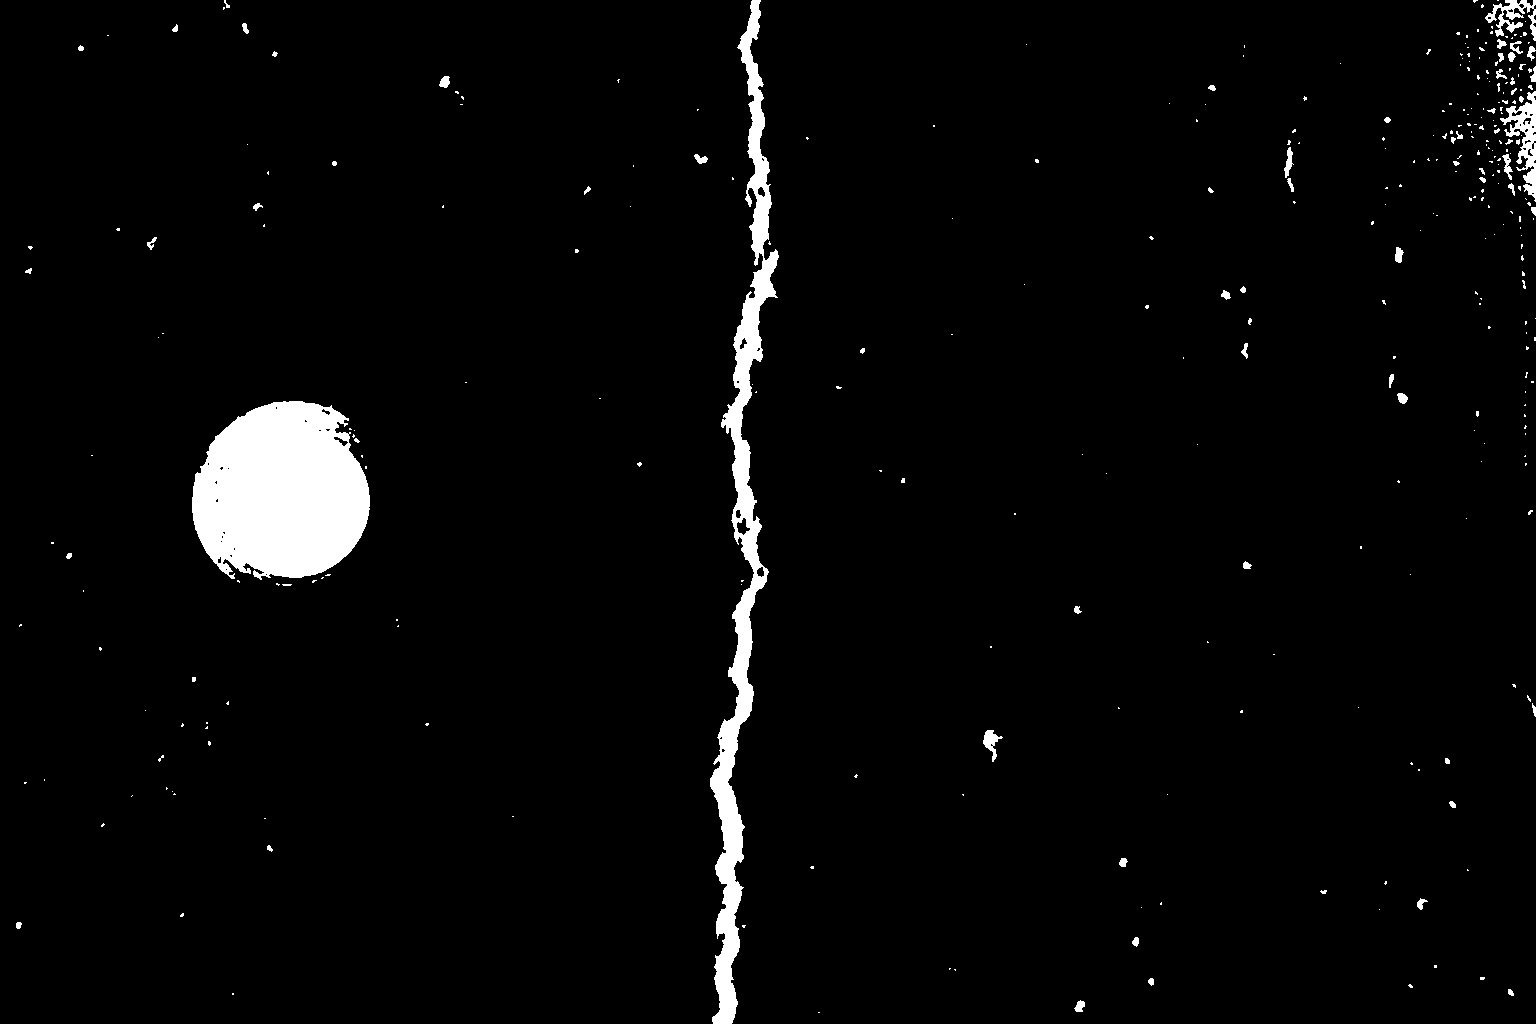

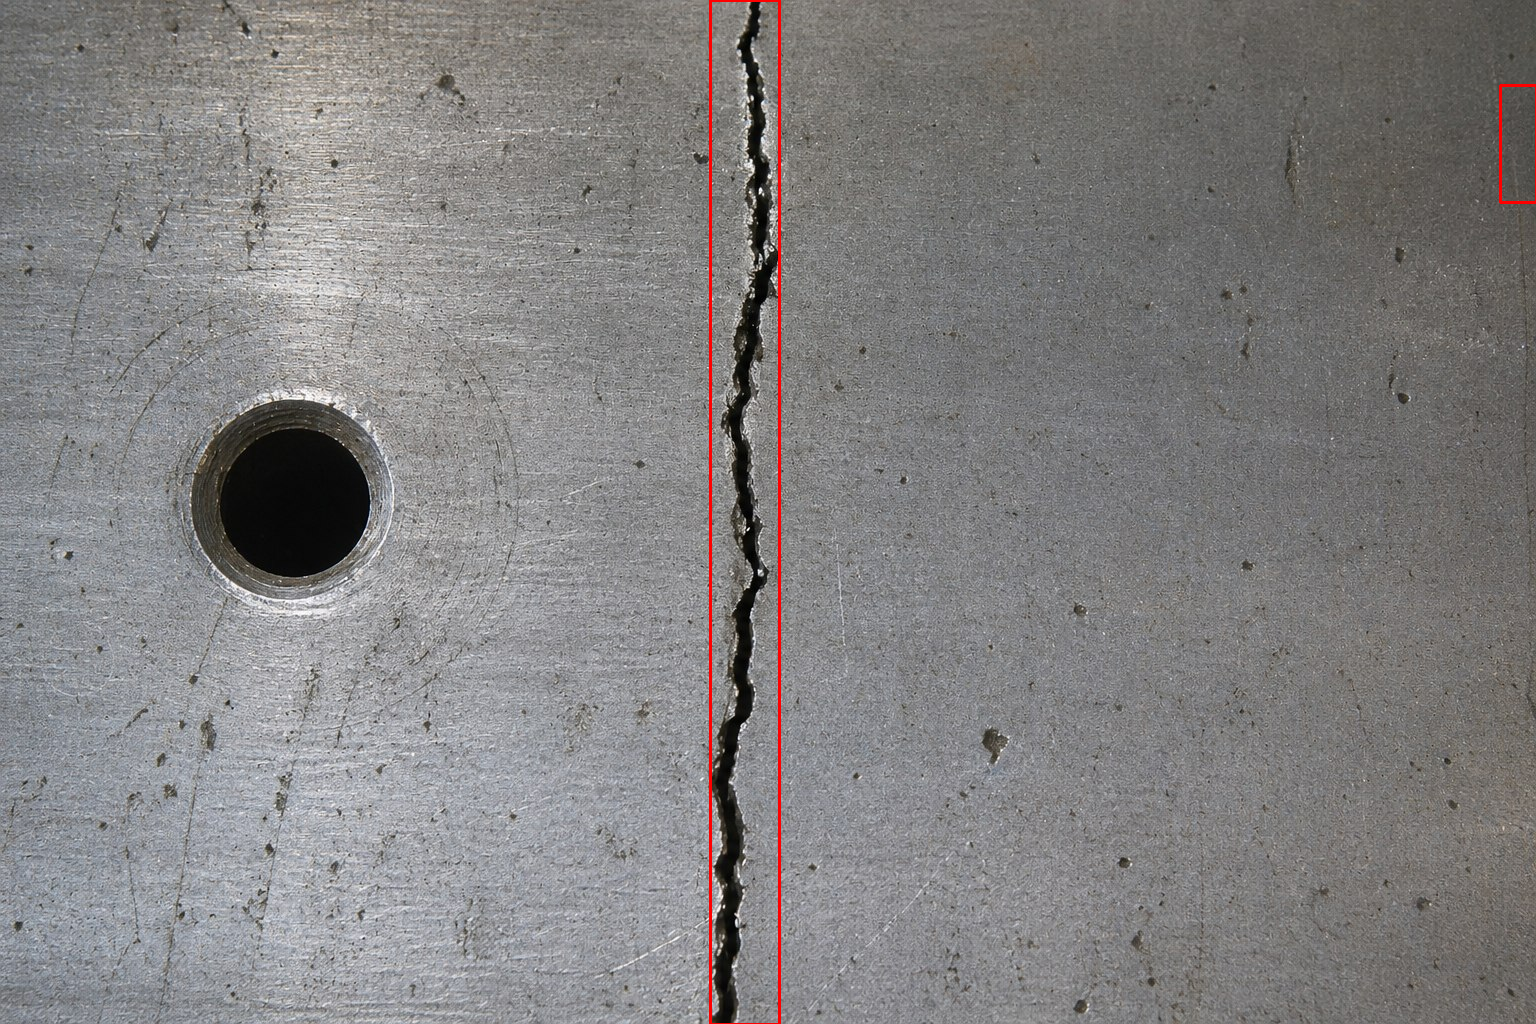

In [5]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load image
image = cv2.imread("image_processing.jpg")

# Check if image was loaded successfully
if image is None:
    print("Error: Could not load image 'image_processing.jpg'. Please ensure the file exists and the path is correct.")
    # No further processing if image is not loaded
else:
    original = image.copy()

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Reduce noise
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # Detect dark crack using inverse threshold
    _, thresh = cv2.threshold(blur, 80, 255, cv2.THRESH_BINARY_INV)

    # Morphological operations to connect crack regions
    kernel = np.ones((3, 3), np.uint8)
    morph = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel, iterations=1)

    # Find contours
    contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Draw detected crack area
    for cnt in contours:
        area = cv2.contourArea(cnt)

        # Ignore tiny noise
        if area > 100:
            x, y, w, h = cv2.boundingRect(cnt)

            # Optional: focus on tall narrow crack-like objects
            if h > 100 and w < 80:
                cv2.rectangle(original, (x, y), (x+w, y+h), (0, 0, 255), 2)

    # Save and display
    cv2.imwrite("detected_crack.jpg", original)

    cv2_imshow(thresh)
    cv2_imshow(original)
    cv2.waitKey(0)
    cv2.destroyAllWindows()